In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from ast import literal_eval

# 데이터 구조 확인

## 데이터 이름, 컬럼명 통일

In [2]:
df_transcript = pd.read_csv('./transcript.csv', index_col=0)
df_customer = pd.read_csv('./profile.csv', index_col=0)
df_promotion = pd.read_csv('./portfolio.csv', index_col=0)
display(df_transcript, df_customer, df_promotion)

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
...,...,...,...,...,...
16995,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,20180604,54000.0
16996,M,61,2cb4f97358b841b9a9773a7aa05a9d77,20180713,72000.0
16997,M,49,01d26f638c274aa0b965d24cefe3183f,20170126,73000.0
16998,F,83,9dc1421481194dcd9400aec7c9ae6366,20160307,50000.0


,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [129]:
df_transcript = df_transcript.rename(columns={'person': 'person_id'})

In [130]:
df_promotion = df_promotion.rename(columns = {'reward': 'promotion_reward'})
df_promotion = df_promotion.rename(columns = {'id': 'promotion_id'})


## 테이블 구조 확인

In [131]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               17000 non-null  int64  
 2   id                17000 non-null  object 
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 796.9+ KB


In [132]:
df_promotion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   promotion_reward  10 non-null     int64 
 1   channels          10 non-null     object
 2   difficulty        10 non-null     int64 
 3   duration          10 non-null     int64 
 4   offer_type        10 non-null     object
 5   promotion_id      10 non-null     object
dtypes: int64(3), object(3)
memory usage: 560.0+ bytes


In [133]:
df_transcript.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306534 entries, 0 to 306533
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  306534 non-null  object
 1   event      306534 non-null  object
 2   value      306534 non-null  object
 3   time       306534 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 11.7+ MB


## 결측치 제거

In [134]:
df_transcript.isna().sum()

person_id    0
event        0
value        0
time         0
dtype: int64

In [135]:
df_customer.isna().sum()

gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [136]:
df_promotion.isna().sum()

promotion_reward    0
channels            0
difficulty          0
duration            0
offer_type          0
promotion_id        0
dtype: int64

In [137]:
# gender와 income이 NaN인 데이터는 동일한 데이터
sum(df_customer['gender'].isna() & df_customer['income'].isna())

2175

In [138]:
# NaN 데이터 제거
df_customer = df_customer.dropna(subset=['gender', 'income'], how='all').reset_index(drop=True)
df_customer

,gender,age,id,became_member_on,income
0,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
1,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
2,M,68,e2127556f4f64592b11af22de27a7932,20180426,70000.0
3,M,65,389bc3fa690240e798340f5a15918d5c,20180209,53000.0
4,M,58,2eeac8d8feae4a8cad5a6af0499a211d,20171111,51000.0
...,...,...,...,...,...
14820,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,20180604,54000.0
14821,M,61,2cb4f97358b841b9a9773a7aa05a9d77,20180713,72000.0
14822,M,49,01d26f638c274aa0b965d24cefe3183f,20170126,73000.0
14823,F,83,9dc1421481194dcd9400aec7c9ae6366,20160307,50000.0


In [139]:
# 결측치 제거 확인
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14825 entries, 0 to 14824
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               14825 non-null  int64  
 2   id                14825 non-null  object 
 3   became_member_on  14825 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 579.2+ KB


## 중복값 제거

In [140]:
# 고객 데이터 중복값 확인 → 중복값 없음
len(df_customer['id'].unique())

14825

In [141]:
duplicates = df_transcript.duplicated() # 모든 컬럼대상 중복값 확인. 첫번째 등장행은 False 상태 기본값
print(f"중복된 행의 개수: {duplicates.sum()}")

중복된 행의 개수: 397


In [142]:
# 중복값 제거
df_transcript = df_transcript.drop_duplicates() # keep='first' 기본값

In [143]:
df_transcript = df_transcript.reset_index(drop=True)
df_transcript

,person_id,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
306132,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306133,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306134,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306135,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714


In [144]:
df_transcript.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  306137 non-null  object
 1   event      306137 non-null  object
 2   value      306137 non-null  object
 3   time       306137 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 9.3+ MB


# 데이터 형태 변환

## 딕셔너리 형태 변환

In [3]:
# 함수 정의
def convert_to_dict(val):
    # 이미 딕셔너리라면 그대로 반환
    # isinstance(): 객체가 특정 타입인지 확인
    if isinstance(val, dict):
        return val
    try:
        # 문자열을 딕셔너리 객체로 변환
        return literal_eval(val)
    except (ValueError, SyntaxError):
        # 변환 불가능한 경우 빈 딕셔너리 반환
        return {}

# value 컬럼에 적용
value_dic = df_transcript['value'].apply(convert_to_dict)

In [4]:
# 모든 키값 확인
# set.union(*[set(dic.keys()) for dic in df_transcript['value']])
set().union(*value_dic)

{'amount', 'offer id', 'offer_id', 'reward'}

In [5]:
# 딕셔너리 변환 컬럼
df_transcript['value'] = value_dic

# amount 컬럼 
df_transcript['amount'] = df_transcript['value'].apply(lambda x: x.get('amount'))

# 'offer_id' 추출: 'offer_id'와 'offer id' 두 케이스 모두 대응
df_transcript['offer_id'] = df_transcript['value'].apply(
    lambda x: x.get('offer_id') or x.get('offer id')
)

# 'reward' 추출
df_transcript['reward'] = df_transcript['value'].apply(lambda x: x.get('reward'))

# value 컬럼 삭제
df_transcript = df_transcript.drop('value', axis=1)

In [8]:
df_transcript.event.unique()

array(['offer received', 'offer viewed', 'transaction', 'offer completed'],
      dtype=object)

In [6]:
df_transcript = df_transcript[['person_id', 'event', 'amount', 'offer_id', 'reward', 'time']]
df_transcript

KeyError: "['person_id'] not in index"

In [149]:
# 1. reward 컬럼이 결측치가 아닌(not null) 행만 추출
reward_not_null = df_transcript[df_transcript['reward'].notna()]

# 2. 이 행들이 어떤 이벤트들로 구성되어 있는지 카운트
print("--- reward가 존재하는 행들의 이벤트 구성 ---")
print(reward_not_null['event'].value_counts())

# 3. 실제 데이터 샘플 확인 (상위 5개)
print("\n--- reward 존재 데이터 샘플 ---")
display(reward_not_null[['person_id', 'time', 'event', 'reward']].head())

--- reward가 존재하는 행들의 이벤트 구성 ---
event
offer completed    33182
Name: count, dtype: int64

--- reward 존재 데이터 샘플 ---


,person_id,time,event,reward
12658,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,0,offer completed,2.0
12672,fe97aa22dd3e48c8b143116a8403dd52,0,offer completed,2.0
12679,629fc02d56414d91bca360decdfa9288,0,offer completed,5.0
12692,676506bad68e4161b9bbaffeb039626b,0,offer completed,10.0
12697,8f7dd3b2afe14c078eb4f6e6fe4ba97d,0,offer completed,10.0


## channels 리스트 분리해서 컬럼 생성

In [150]:
#channels -> web, email, mobile, social 별 컬럼으로 나누어 0과 1로 표현(ex. web, mobile : web 1 email 0 mobile 1 social 0) 
#대상 채널 리스트 정의
channel_list = ['web', 'email', 'mobile', 'social']

#각 채널별로 컬럼을 만들고 1 또는 0 채우기
for channel in channel_list:
    # 포함 여부 확인
    df_promotion[channel] = df_promotion['channels'].apply(lambda x: 1 if channel in str(x) else 0)

# 채널 컬럼 삭제
df_promotion = df_promotion.drop('channels', axis=1)
df_promotion = df_promotion[['promotion_reward', 'web', 'email', 'mobile', 'social', 'difficulty', 'duration', 'offer_type', 'promotion_id']]
df_promotion

,promotion_reward,web,email,mobile,social,difficulty,duration,offer_type,promotion_id
0,10,0,1,1,1,10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,1,1,1,1,10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,1,1,1,0,0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,1,1,1,0,5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,1,1,0,0,20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,1,1,1,1,7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,1,1,1,1,10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,0,1,1,1,0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,1,1,1,1,5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,1,1,1,0,10,7,discount,2906b810c7d4411798c6938adc9daaa5


# 이상치

## 로그변환 후 이상치 제거

In [151]:
df_transcript['log_amount'] = np.log1p(df_transcript['amount']) 

In [152]:
# IQR

df1 = df_transcript[['log_amount']]

q3 = df1['log_amount'].quantile(0.75) 
q1 = df1['log_amount'].quantile(0.25)

iqr = q3 - q1
q3, q1, iqr

def is_outlier(df1):
    score = df1['log_amount']
    if score > q3 + (1.5 * iqr) or score < q1 - (1.5 * iqr):
        return '이상치'
    else:
        return '이상치아님'

In [153]:
df_transcript['이상치여부'] = df_transcript.apply(is_outlier, axis = 1)

In [154]:
df_transcript.groupby('이상치여부').size()

이상치여부
이상치         364
이상치아님    305773
dtype: int64

In [155]:
# z-score
df2 = df_transcript[['log_amount']]

df2['zscore'] =  StandardScaler().fit_transform(df2)
df2['zscore'].head()

C:\Users\user\AppData\Local\Temp\ipykernel_19344\1682567732.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zscore'] =  StandardScaler().fit_transform(df2)


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: zscore, dtype: float64

In [156]:

df_transcript['zscore이상치여부'] = df2['zscore'].apply(lambda x: 'z이상치' if ( x < -3 or x > 3) else 'z이상치아님')
df_transcript.groupby('zscore이상치여부', dropna=False).size()

zscore이상치여부
z이상치         382
z이상치아님    305755
dtype: int64

In [157]:
#iqr - zscore
df_transcript_outlier = df_transcript[(df_transcript['이상치여부'] == '이상치') & (df_transcript['zscore이상치여부'] == 'z이상치')]
df_transcript_outlier.head()

,person_id,event,amount,offer_id,reward,time,log_amount,이상치여부,zscore이상치여부
18053,8a776d222f174aa089866b2725721eec,transaction,448.97,None,NaN,6,6.109181,이상치,z이상치
18417,6b247ba48509456eb57b24f878f313ea,transaction,219.02,None,NaN,12,5.393718,이상치,z이상치
18800,04f1f44632cd409cace939fa62b5fc7a,transaction,628.41,None,NaN,12,6.444783,이상치,z이상치
19097,a12fba072dae4e3aae2e1b4b92b92aa1,transaction,871.51,None,NaN,12,6.771374,이상치,z이상치
19365,7deb44388feb4a9ea7681464bf16b8dd,transaction,276.36,None,NaN,12,5.625316,이상치,z이상치


In [158]:
idx = df_transcript[(df_transcript['이상치여부'] == '이상치') & (df_transcript['zscore이상치여부'] == 'z이상치')].index
df_transcript.drop(idx , inplace=True)

## 이상치 확인

In [159]:
df_customer['age'].max()

101

In [160]:
len(df_customer[df_customer['age'] >= 100])

17

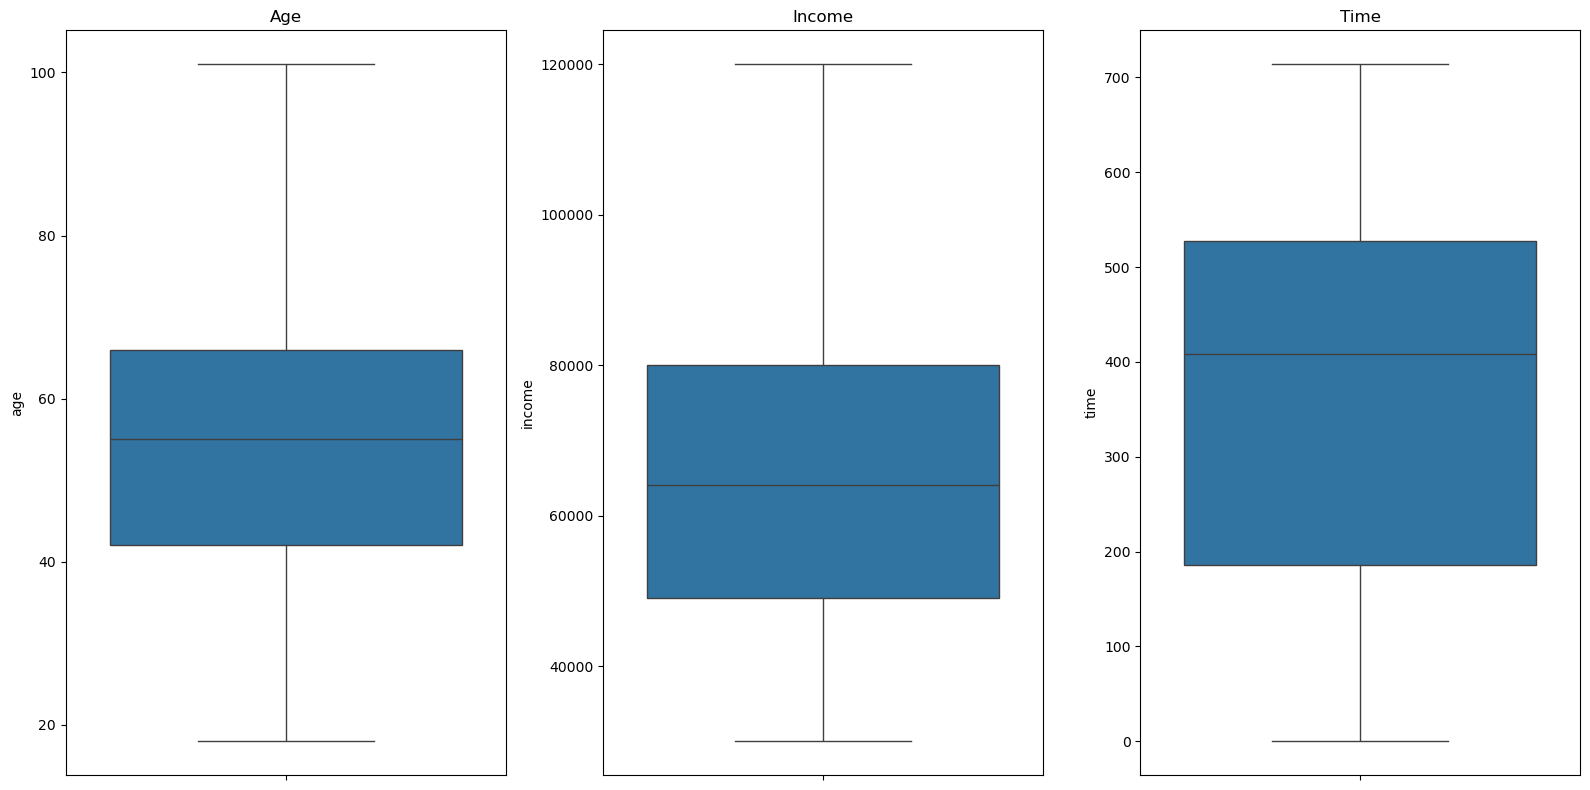

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(16,8))

sns.boxplot(df_customer['age'], ax=axes[0])
axes[0].set_title('Age')

sns.boxplot(df_customer['income'], ax=axes[1])
axes[1].set_title('Income')

sns.boxplot(df_transcript['time'], ax=axes[2])
axes[2].set_title('Time')

plt.tight_layout()
plt.show()

In [162]:
df_transcript.to_csv('./event_log.csv')
df_customer.to_csv('./customer.csv')
df_promotion.to_csv('./promotion.csv')

# transactions에 offer_id 부여

In [164]:
def phase1_generate_offer_id(df_transcript):
    df = df_transcript.sort_values(['person_id', 'time']).copy()
    
    # 임시 컬럼 생성
    df['assigned_id'] = np.nan
    df['match_source'] = np.nan
    df['viewed_time'] = np.nan  # <--- [중요] 오퍼 본 시간을 저장할 컬럼 추가

    for p_id, group in df.groupby('person_id'):
        transactions = group[group['event'] == 'transaction']
        completed = group[group['event'] == 'offer completed']
        viewed = group[group['event'] == 'offer viewed']
        
        for idx, t_row in transactions.iterrows():
            t_time = t_row['time']
            
            # [조건 1] Completed 시간 일치
            exact_comp = completed[completed['time'] == t_time]
            if not exact_comp.empty:
                last_comp = exact_comp.iloc[-1]
                df.at[idx, 'assigned_id'] = last_comp['offer_id']
                df.at[idx, 'match_source'] = 'completed'
                # completed인 경우, 해당 오퍼를 가장 최근에 본 시간을 찾아 기록
                last_view = viewed[viewed['time'] <= t_time].sort_values('time', ascending=False)
                if not last_view.empty:
                    df.at[idx, 'viewed_time'] = last_view.iloc[0]['time']
                continue
            
            # [조건 2] 직전 Viewed 존재
            past_views = viewed[viewed['time'] <= t_time].sort_values('time', ascending=False)
            if not past_views.empty:
                df.at[idx, 'assigned_id'] = past_views.iloc[0]['offer_id']
                df.at[idx, 'match_source'] = 'viewed'
                # [중요] offer_viewed 행의 'time' 값을 viewed_time 컬럼에 저장
                df.at[idx, 'viewed_time'] = past_views.iloc[0]['time'] 
    
    df['offer_id'] = df['offer_id'].fillna(df['assigned_id'])
    df = df.drop(columns=['assigned_id'])
    
    return df

# 1단계 실행
df_step1 = phase1_generate_offer_id(df_transcript)

C:\Users\user\AppData\Local\Temp\ipykernel_19344\1165530851.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5a8bc65990b245e5a138643cd4eb9837' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, 'assigned_id'] = past_views.iloc[0]['offer_id']
C:\Users\user\AppData\Local\Temp\ipykernel_19344\1165530851.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'viewed' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, 'match_source'] = 'viewed'


In [ ]:
# promotion_id를 키로, difficulty를 포함한 스펙을 밸류로
promo_lookup = df_promotion.set_index('promotion_id').to_dict('index')

In [ ]:
# --- 이 코드를 복사해서 새로 실행해 보세요 ---
def check_insufficient_amount_fast(df_step1, df_promotion):
    # 1. 비교를 위한 difficulty 정보 미리 준비
    promo_info = df_promotion[['promotion_id', 'difficulty']]
    
    # 2. completed와 transaction만 분리
    comp = df_step1[df_step1['event'] == 'offer completed'][['person_id', 'time', 'offer_id']]
    trans = df_step1[df_step1['event'] == 'transaction'][['person_id', 'time', 'amount']]
    
    # 3. [핵심] 병합(Merge)을 통해 동일인물 & 동일시간 짝을 한 번에 찾기
    merged = pd.merge(comp, trans, on=['person_id', 'time'], how='inner')
    
    # 4. 난이도(difficulty) 정보 붙이기
    merged = pd.merge(merged, promo_info, left_on='offer_id', right_on='promotion_id', how='left')
    
    # 5. 한 번에 계산 (Vectorized Operation)
    insufficient = merged[merged['amount'] < merged['difficulty']].copy()
    insufficient['gap'] = insufficient['difficulty'] - insufficient['amount']
    
    return insufficient

# 실행 (거의 즉시 끝납니다)
insufficient_df = check_insufficient_amount_fast(df_step1, df_promotion)
print(f"발견된 부족 케이스: {len(insufficient_df)}건")

발견된 부족 케이스: 4621건


In [ ]:
# 1. 4,621건 중 첫 번째 샘플 ID 추출
sample_case = insufficient_df.iloc[0]
sample_id = sample_case['person_id']
target_offer_id = sample_case['offer_id']

print(f"🔍 분석 대상 ID: {sample_id}")
print(f"🎯 타겟 오퍼 ID: {target_offer_id} (난이도: {sample_case['difficulty']})")
print(f"⚠️ 완료 시점 결제액: {sample_case['amount']} (부족분: {sample_case['gap']})")
print("-" * 50)

# 2. 해당 사용자의 전체 히스토리 추출 (시간순)
# df_step1이나 1단계가 완료된 데이터프레임을 사용하세요.
sample_history = df_step1[df_step1['person_id'] == sample_id].sort_values('time')

# 3. 주요 컬럼만 보기 좋게 출력
display(sample_history[['time', 'event', 'offer_id', 'amount']])

🔍 분석 대상 ID: 003d66b6608740288d6cc97a6903f4f0
🎯 타겟 오퍼 ID: fafdcd668e3743c1bb461111dcafc2a4 (난이도: 10)
⚠️ 완료 시점 결제액: 3.66 (부족분: 6.34)
--------------------------------------------------


,time,event,offer_id,amount
2652,0,offer received,5a8bc65990b245e5a138643cd4eb9837,NaN
27148,36,offer viewed,5a8bc65990b245e5a138643cd4eb9837,NaN
34967,66,transaction,5a8bc65990b245e5a138643cd4eb9837,0.44
36353,72,transaction,5a8bc65990b245e5a138643cd4eb9837,2.07
55857,168,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN
82580,204,transaction,5a8bc65990b245e5a138643cd4eb9837,1.48
105494,300,offer viewed,fafdcd668e3743c1bb461111dcafc2a4,NaN
109509,324,transaction,fafdcd668e3743c1bb461111dcafc2a4,0.89
110407,330,transaction,fafdcd668e3743c1bb461111dcafc2a4,2.29
113459,336,offer received,3f207df678b143eea3cee63160fa8bed,NaN


In [ ]:
df_transcript[df_transcript['amount'] < 1]

,person_id,event,amount,offer_id,reward,time,log_amount,이상치여부,zscore이상치여부
12654,02c083884c7d45b39cc68e1314fec56c,transaction,0.83,None,NaN,0,0.604316,이상치아님,z이상치아님
12686,bbeb54e861614fc7b22a8844f72dca6c,transaction,0.22,None,NaN,0,0.198851,이상치아님,z이상치아님
12724,c2c72ce6038644c797208046d1e3498a,transaction,0.75,None,NaN,0,0.559616,이상치아님,z이상치아님
12967,db691240326b44d8bfa7b438c4c41982,transaction,0.05,None,NaN,0,0.048790,이상치아님,z이상치아님
13117,3f7ac208f7e844cab207ceb8e42177ba,transaction,0.23,None,NaN,0,0.207014,이상치아님,z이상치아님
...,...,...,...,...,...,...,...,...,...
306061,60f9f0df41b544a5b243952d8a89541c,transaction,0.64,None,NaN,714,0.494696,이상치아님,z이상치아님
306069,9b84c5f2038e4f638813091d3565a8f0,transaction,0.15,None,NaN,714,0.139762,이상치아님,z이상치아님
306074,791c42c7a024458eae95a5540f69df14,transaction,0.25,None,NaN,714,0.223144,이상치아님,z이상치아님
306088,4b59509988d34c7298119a840c946453,transaction,0.06,None,NaN,714,0.058269,이상치아님,z이상치아님


# 수정사항

In [ ]:
def phase2_confirm_offer_id(df_step1, df_promotion):
    df = df_step1.copy()
    
    # 1. 초기화: 기본값 설정
    df['purchase_type'] = 'organic'
    processed_indices = set() 

    # 프로모션 정보 딕셔너리 (유효기간 체크용)
    promo_lookup = df_promotion.set_index('promotion_id').to_dict('index')

    for p_id, group in df.groupby('person_id'):
        completed_events = group[group['event'] == 'offer completed'].sort_values('time')
        transactions = group[group['event'] == 'transaction'].sort_values('time')

        # --- [Step A] Completed 오퍼 처리 (백트래킹 포함) ---
        for _, c_row in completed_events.iterrows():
            c_time, c_offer_id = c_row['time'], c_row['offer_id']
            specs = promo_lookup.get(c_offer_id)
            if not specs: continue
            
            same_time_trans = transactions[transactions['time'] == c_time]
            
            if not same_time_trans.empty:
                current_idx = same_time_trans.index[0]
                total_amount = df.at[current_idx, 'amount']
                match_indices = [current_idx]
                
                # 난이도 충족을 위한 백트래킹
                if total_amount < specs['difficulty']:
                    past_trans = transactions[transactions['time'] < c_time].sort_values('time', ascending=False)
                    for p_idx, p_row in past_trans.iterrows():
                        if total_amount >= specs['difficulty']: break
                        if p_idx not in processed_indices:
                            total_amount += p_row['amount']
                            match_indices.append(p_idx)

                # 매칭된 결제에 ID 부여 및 라벨링
                for m_idx in match_indices:
                    df.at[m_idx, 'offer_id'] = c_offer_id
                    df.at[m_idx, 'purchase_type'] = 'influenced(exact_complete)'
                    processed_indices.add(m_idx)

        # --- [Step B] 남은 결제 처리 (viewed_time 결측치 방어) ---
        remaining_trans = transactions[~transactions.index.isin(processed_indices)]
        for t_idx, t_row in remaining_trans.iterrows():
            t_id, v_time = t_row['offer_id'], t_row['viewed_time']
            
            # [방어] ID와 본 시간(viewed_time)이 둘 다 있을 때만 유효기간 계산
            if pd.notna(t_id) and pd.notna(v_time):
                spec = promo_lookup.get(t_id)
                if spec:
                    is_time_ok = v_time <= t_row['time'] <= v_time + (spec['duration'] * 24)
                    if is_time_ok:
                        df.at[t_idx, 'purchase_type'] = "influenced(viewed_only)"
                        processed_indices.add(t_idx)
                        continue 
            
            # [클리닝] 조건 미달 시 Organic 강등 및 정보 삭제
            df.at[t_idx, 'purchase_type'] = 'organic'
            df.at[t_idx, 'offer_id'] = np.nan # ID를 지워야 나중에 Merge할 때 리워드가 안 붙음

    return df

In [166]:
# 1. 2단계 실행
df_final = phase2_confirm_offer_id(df_step1, df_promotion)

In [167]:
# 2. 최종 Merge (확정된 ID를 기준으로 상세 정보 결합)
df_final = pd.merge(df_final, df_promotion, left_on='offer_id', right_on='promotion_id', how='left')

In [168]:
# 4. 결과 확인
print(df_final['purchase_type'].value_counts())

purchase_type
organic                       191362
influenced(exact_complete)     38917
influenced(bogo)               34981
influenced(discount)           29802
influenced(informational)      10711
Name: count, dtype: int64


In [169]:
# 'organic'으로 분류된 결제들 중, 사실은 오퍼 기간(Duration)을 아깝게 넘긴 것들이 많은지 확인
df_check = df_final[df_final['purchase_type'] == 'organic'].copy()

# 오퍼를 보긴 했는데 기간만 지난 케이스가 있는지 체크
late_buyers = df_check[df_check['viewed_time'].notna()]
print(f"오퍼를 보긴 했지만 기간이 지나 organic이 된 건수: {len(late_buyers)}건")

오퍼를 보긴 했지만 기간이 지나 organic이 된 건수: 14180건


In [170]:
#customer라 합침
# 1. 고객 데이터의 'id'를 'person_id'로 미리 바꿉니다.
df_customer_renamed = df_customer.rename(columns={'id': 'person_id'})

In [171]:
# 2. 이제 같은 이름('person_id')을 기준으로 합칩니다.
# 이렇게 하면 Pandas가 두 컬럼을 하나로 합쳐버려서 중복 데이터가 안 생깁니다!
df_total = pd.merge(df_final, df_customer_renamed, on='person_id', how='left')

## csv로 파일 저장

In [172]:
df_transcript.to_csv('./event_log.csv')
df_customer.to_csv('./customer.csv')
df_promotion.to_csv('./promotion.csv')

In [173]:
df_total.to_csv('./starbucks_merged_real_final.csv')